<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Delivery_ID        20 non-null     object 
 1   Partner_Name       20 non-null     object 
 2   Distance_km        20 non-null     int64  
 3   Traffic_Level      20 non-null     object 
 4   Delivery_Time_min  20 non-null     int64  
 5   Fuel_Cost          20 non-null     int64  
 6   Vehicle_Type       20 non-null     object 
 7   Orders_Per_Route   20 non-null     int64  
 8   Latitude           20 non-null     float64
 9   Longitude          20 non-null     float64
 10  On_Time            20 non-null     object 
dtypes: float64(2), int64(4), object(5)
memory usage: 1.8+ KB
Average Delivery Time by Traffic Level:
Traffic_Level
High      47.0
Low       18.0
Medium    28.0
Name: Delivery_Time_min, dtype: float64
Average Fuel Cost by Vehicle Type:
Vehicle_Type
Bike    45.9
Van     90.

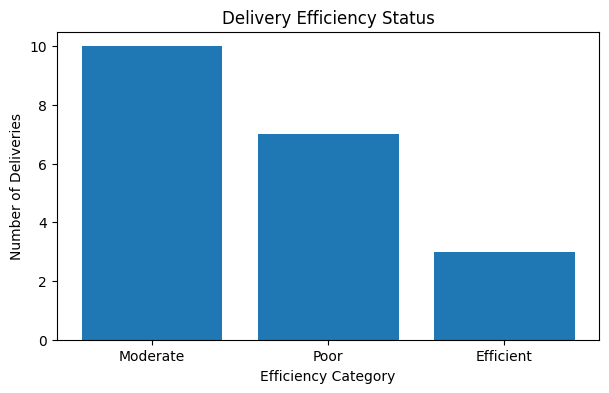

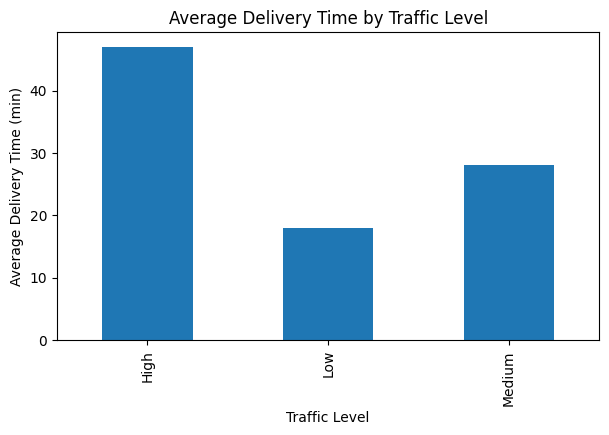

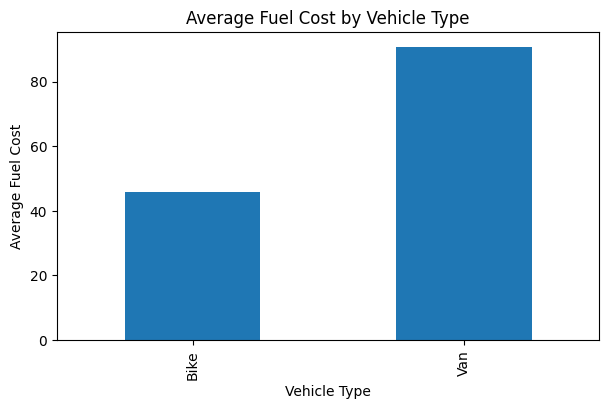

Warehouse Latitude: 28.613
Warehouse Longitude: 77.2095
Optimized Delivery Route:
['D017', 'D001', 'D014', 'D002', 'D008', 'D003', 'D015', 'D010', 'D005', 'D018', 'D019', 'D006', 'D009', 'D012', 'D013', 'D016', 'D004', 'D020', 'D007', 'D011']
Original Route:
['D001', 'D002', 'D003', 'D004', 'D005', 'D006', 'D007', 'D008', 'D009', 'D010', 'D011', 'D012', 'D013', 'D014', 'D015', 'D016', 'D017', 'D018', 'D019', 'D020']

Optimized Route:
['D017', 'D001', 'D014', 'D002', 'D008', 'D003', 'D015', 'D010', 'D005', 'D018', 'D019', 'D006', 'D009', 'D012', 'D013', 'D016', 'D004', 'D020', 'D007', 'D011']


In [1]:
# Cell 1
# Import all libraries needed for data handling, visualization,
# route logic, machine learning, and clustering

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans


# Cell 2
# Create a sample logistics dataset with:
# delivery details, GPS coordinates, vehicle type, partner name,
# traffic level, fuel cost, and on-time delivery status

data = {
    "Delivery_ID": ["D001", "D002", "D003", "D004", "D005", "D006", "D007", "D008", "D009", "D010",
                    "D011", "D012", "D013", "D014", "D015", "D016", "D017", "D018", "D019", "D020"],

    "Partner_Name": ["Amit", "Riya", "Sohan", "Amit", "Riya", "Sohan", "Neha", "Kiran", "Amit", "Riya",
                     "Sohan", "Neha", "Kiran", "Amit", "Riya", "Sohan", "Neha", "Kiran", "Amit", "Riya"],

    "Distance_km": [5, 8, 12, 4, 10, 15, 7, 6, 14, 9,
                    5, 11, 13, 6, 8, 16, 7, 10, 12, 5],

    "Traffic_Level": ["Low", "Medium", "High", "Low", "Medium", "High", "Low", "Medium", "High", "Medium",
                      "Low", "High", "High", "Medium", "Low", "High", "Medium", "Medium", "High", "Low"],

    "Delivery_Time_min": [18, 28, 45, 15, 30, 52, 20, 24, 48, 32,
                          17, 40, 46, 25, 22, 55, 26, 31, 43, 16],

    "Fuel_Cost": [40, 60, 95, 35, 70, 110, 45, 50, 100, 68,
                  38, 88, 98, 48, 55, 115, 52, 72, 92, 36],

    "Vehicle_Type": ["Bike", "Bike", "Van", "Bike", "Van", "Van", "Bike", "Bike", "Van", "Van",
                     "Bike", "Van", "Van", "Bike", "Bike", "Van", "Bike", "Van", "Van", "Bike"],

    "Orders_Per_Route": [2, 3, 4, 1, 3, 5, 2, 2, 4, 3,
                         1, 4, 4, 2, 2, 5, 3, 3, 4, 1],

    "Latitude": [28.6139, 28.6145, 28.6160, 28.6125, 28.6180, 28.6205, 28.6110, 28.6152, 28.6210, 28.6173,
                 28.6105, 28.6220, 28.6235, 28.6140, 28.6168, 28.6242, 28.6130, 28.6185, 28.6200, 28.6118],

    "Longitude": [77.2090, 77.2105, 77.2120, 77.2080, 77.2140, 77.2165, 77.2070, 77.2110, 77.2175, 77.2132,
                  77.2065, 77.2180, 77.2195, 77.2100, 77.2128, 77.2202, 77.2088, 77.2148, 77.2160, 77.2078],

    "On_Time": ["Yes", "Yes", "No", "Yes", "Yes", "No", "Yes", "Yes", "No", "Yes",
                "Yes", "No", "No", "Yes", "Yes", "No", "Yes", "Yes", "No", "Yes"]
}

df = pd.DataFrame(data)

# Display first 5 rows of the dataset
df.head()


# Cell 3
# Display the complete logistics dataset

df


# Cell 4
# Check column names, data types, and non-null values

df.info()


# Cell 5
# Verify whether there are any missing values in the dataset

df.isnull().sum()


# Cell 6
# Generate summary statistics for numeric columns

df.describe()


# Cell 7
# Calculate fuel cost per kilometer
# This helps us understand route cost efficiency

df["Cost_Per_Km"] = df["Fuel_Cost"] / df["Distance_km"]

# Display updated dataset
df.head()


# Cell 8
# Calculate average delivery speed in km per minute
# Speed = distance traveled / delivery time

df["Speed_km_per_min"] = df["Distance_km"] / df["Delivery_Time_min"]

# Display updated dataset
df.head()


# Cell 9
# Convert On_Time status into numeric delay flag
# Delay = 0 means on-time delivery
# Delay = 1 means delayed delivery

df["Delay"] = df["On_Time"].map({"Yes": 0, "No": 1})

# Display updated dataset
df.head()


# Cell 10
# Create a business-friendly efficiency category
# Efficient -> on-time and lower cost
# Moderate -> on-time but cost is relatively high
# Poor -> delayed delivery

def classify_efficiency(row):
    if row["On_Time"] == "Yes" and row["Cost_Per_Km"] <= 7:
        return "Efficient"
    elif row["On_Time"] == "Yes" and row["Cost_Per_Km"] > 7:
        return "Moderate"
    else:
        return "Poor"

df["Efficiency_Status"] = df.apply(classify_efficiency, axis=1)

# Display updated dataset
df.head()


# Cell 11
# Count how many deliveries fall into each efficiency category

df["Efficiency_Status"].value_counts()


# Cell 12
# Calculate average delivery time for each traffic category

avg_time_by_traffic = df.groupby("Traffic_Level")["Delivery_Time_min"].mean()

print("Average Delivery Time by Traffic Level:")
print(avg_time_by_traffic)


# Cell 13
# Calculate average fuel cost for each vehicle type

avg_cost_by_vehicle = df.groupby("Vehicle_Type")["Fuel_Cost"].mean()

print("Average Fuel Cost by Vehicle Type:")
print(avg_cost_by_vehicle)


# Cell 14
# Count number of on-time and delayed deliveries

df["On_Time"].value_counts()


# Cell 15
# Show deliveries with the highest delivery times
# These may require operational attention

df.sort_values(by="Delivery_Time_min", ascending=False).head(5)


# Cell 16
# Show deliveries with the highest fuel cost
# These may be expensive or inefficient routes

df.sort_values(by="Fuel_Cost", ascending=False).head(5)


# Cell 17
# Plot delivery efficiency categories

efficiency_counts = df["Efficiency_Status"].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(efficiency_counts.index, efficiency_counts.values)
plt.title("Delivery Efficiency Status")
plt.xlabel("Efficiency Category")
plt.ylabel("Number of Deliveries")
plt.show()


# Cell 18
# Plot average delivery time across traffic levels

avg_time_by_traffic.plot(kind="bar", figsize=(7, 4))
plt.title("Average Delivery Time by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Time (min)")
plt.show()


# Cell 19
# Plot average fuel cost for each vehicle type

avg_cost_by_vehicle.plot(kind="bar", figsize=(7, 4))
plt.title("Average Fuel Cost by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Fuel Cost")
plt.show()


# Part A: GPS Intelligence and Route Optimization
# Cell 20
# Define a simple Euclidean distance function for GPS coordinates
# This is used for classroom demonstration of location-based routing

def gps_distance(lat1, lon1, lat2, lon2):
    return sqrt((lat2 - lat1)**2 + (lon2 - lon1)**2)


# Cell 21
# Assume a central warehouse location from where deliveries begin

warehouse_lat = 28.6130
warehouse_lon = 77.2095

print("Warehouse Latitude:", warehouse_lat)
print("Warehouse Longitude:", warehouse_lon)


# Cell 22
# Calculate GPS distance from warehouse to each delivery point

df["Warehouse_GPS_Distance"] = df.apply(
    lambda row: gps_distance(warehouse_lat, warehouse_lon, row["Latitude"], row["Longitude"]),
    axis=1
)

# Display updated dataset
df.head()


# Cell 23
# Sort deliveries based on how close they are to the warehouse

df_sorted_by_distance = df.sort_values(by="Warehouse_GPS_Distance")

df_sorted_by_distance[["Delivery_ID", "Partner_Name", "Warehouse_GPS_Distance"]]


# Cell 24
# Create a simple route optimization using nearest-neighbor logic
# Start from the warehouse and always go to the nearest unvisited delivery point

unvisited = df[["Delivery_ID", "Latitude", "Longitude"]].copy()
route = []

current_lat = warehouse_lat
current_lon = warehouse_lon

while len(unvisited) > 0:
    unvisited["Temp_Distance"] = unvisited.apply(
        lambda row: gps_distance(current_lat, current_lon, row["Latitude"], row["Longitude"]),
        axis=1
    )

    nearest_index = unvisited["Temp_Distance"].idxmin()
    nearest_row = unvisited.loc[nearest_index]

    route.append(nearest_row["Delivery_ID"])

    current_lat = nearest_row["Latitude"]
    current_lon = nearest_row["Longitude"]

    unvisited = unvisited.drop(nearest_index)

print("Optimized Delivery Route:")
print(route)


# Cell 25
# Compare the original delivery order with optimized route order

original_route = df["Delivery_ID"].tolist()

print("Original Route:")
print(original_route)

print("\nOptimized Route:")
print(route)